In [1]:
import requests
import pandas as pd

APP_ID = "f1e89a05"
APP_KEY = "41e5501fd11e347e9050e5393e0b430f"

url = f"https://api.adzuna.com/v1/api/jobs/in/search/1"

params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 50,
    "what": "data analyst",
    "content-type": "application/json"
}

response = requests.get(url, params=params)
data = response.json()

print(response.status_code)
print(data.keys())

200
dict_keys(['__CLASS__', 'results', 'count', 'mean'])


In [2]:
print("Total jobs found:", data['count'])
print()
print("Sample job (first result):")
print(data['results'][0])

Total jobs found: 3388

Sample job (first result):
{'title': 'Climate Data Analyst', 'salary_is_predicted': '0', 'location': {'__CLASS__': 'Adzuna::API::Response::Location', 'area': ['India', 'Maharashtra', 'Pune'], 'display_name': 'Pune, Maharashtra'}, 'id': '5794153830', 'company': {'display_name': 'MSCI', '__CLASS__': 'Adzuna::API::Response::Company'}, 'description': "This job is with MSCI, an inclusive employer and a member of myGwork – the largest global platform for the LGBTQ business community. Please do not contact the recruiter directly. Your Team Responsibilities: The Climate Data and Content team is responsible for research and assessment of carbon footprint and business initiatives related to climate change for approximately 14,000 companies globally. Team's research is focused on climate-related metrics including carbon emissions, energy performanc…", 'latitude': 18.5062, 'created': '2026-07-09T17:58:48Z', '__CLASS__': 'Adzuna::API::Response::Job', 'longitude': 73.84735, '

In [3]:
import time

all_jobs = []
results_per_page = 50
total_pages = 10  

for page in range(1, total_pages + 1):
    url = f"https://api.adzuna.com/v1/api/jobs/in/search/{page}"
    params = {
        "app_id": APP_ID,
        "app_key": APP_KEY,
        "results_per_page": results_per_page,
        "what": "data analyst",
        "content-type": "application/json"
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    if 'results' in data:
        all_jobs.extend(data['results'])
    
    time.sleep(1) 

print("Total jobs collected:", len(all_jobs))

Total jobs collected: 500


In [4]:
all_keys = set()
for job in all_jobs:
    all_keys.update(job.keys())

print("Available fields across all jobs:")
print(all_keys)

salary_count = sum(1 for job in all_jobs if 'salary_min' in job)
print(f"\nJobs with salary info: {salary_count} out of {len(all_jobs)}")

Available fields across all jobs:
{'category', 'redirect_url', 'adref', 'longitude', 'salary_is_predicted', 'salary_max', 'salary_min', 'latitude', 'company', 'contract_time', 'contract_type', 'description', '__CLASS__', 'created', 'title', 'id', 'location'}

Jobs with salary info: 101 out of 500


In [5]:
jobs_list = []

for job in all_jobs:
    jobs_list.append({
        'id': job.get('id'),
        'title': job.get('title'),
        'company': job.get('company', {}).get('display_name'),
        'location': job.get('location', {}).get('display_name'),
        'category': job.get('category', {}).get('label'),
        'contract_type': job.get('contract_type'),
        'contract_time': job.get('contract_time'),
        'created': job.get('created'),
        'salary_min': job.get('salary_min'),
        'salary_max': job.get('salary_max'),
        'salary_is_predicted': job.get('salary_is_predicted'),
        'description': job.get('description'),
        'redirect_url': job.get('redirect_url')
    })

df = pd.DataFrame(jobs_list)
print(df.shape)
df.head()

(500, 13)


,id,title,company,location,category,contract_type,contract_time,created,salary_min,salary_max,salary_is_predicted,description,redirect_url
0,5794153830,Climate Data Analyst,MSCI,"Pune, Maharashtra",Scientific & QA Jobs,None,full_time,2026-07-09T17:58:48Z,NaN,NaN,0,"This job is with MSCI, an inclusive employer a...",https://www.adzuna.in/land/ad/5794153830?se=Ts...
1,5815611084,Data Analyst- Intern,Criteo,"Gurgaon, Haryana",IT Jobs,contract,part_time,2026-07-25T23:45:31Z,NaN,NaN,0,"This job is with Criteo, an inclusive employer...",https://www.adzuna.in/land/ad/5815611084?se=Ts...
2,5821999957,Senior Data Analyst II,Elsevier,India,IT Jobs,permanent,full_time,2026-07-31T09:50:11Z,NaN,NaN,0,"This job is with Elsevier, an inclusive employ...",https://www.adzuna.in/land/ad/5821999957?se=Ts...
3,5813877231,SAS AML Data Analyst / Tester,Dautom,India,IT Jobs,None,None,2026-07-24T19:00:02Z,NaN,NaN,0,Job Description: SAS AML Data Analyst / Tester...,https://www.adzuna.in/land/ad/5813877231?se=Ts...
4,5785770935,"Data Analyst II, RM - AMER",Criteo,"Gurgaon, Haryana",IT Jobs,None,full_time,2026-07-03T00:54:12Z,NaN,NaN,0,"This job is with Criteo, an inclusive employer...",https://www.adzuna.in/land/ad/5785770935?se=Ts...


In [6]:
df.to_csv('data_analyst_jobs_raw.csv', index=False)
print("Saved!")

Saved!


In [7]:
skills_list = ['Python', 'SQL', 'MySQL', 'Excel', 'Google Sheets', 
               'Power BI', 'Tableau', 'Machine Learning', 
               'Statistics', 'AWS', 'Azure', 'SAS', 'VBA', 
               'Data Visualization', 'Data Modeling', 'Communication']

for skill in skills_list:
    df[skill] = df['description'].str.contains(skill, case=False, na=False)

skill_counts = df[skills_list].sum().sort_values(ascending=False)
print(skill_counts)

SQL                   93
Excel                 68
Python                50
Power BI              39
Communication         34
Tableau               29
Data Visualization    22
AWS                   11
Machine Learning       7
Statistics             7
Azure                  7
Google Sheets          5
SAS                    5
VBA                    5
Data Modeling          4
MySQL                  0
dtype: int64


In [8]:
df = df.drop(columns=['MySQL'])
skills_list.remove('MySQL')

C:\Users\vaish\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  from scipy.stats import gaussian_kde


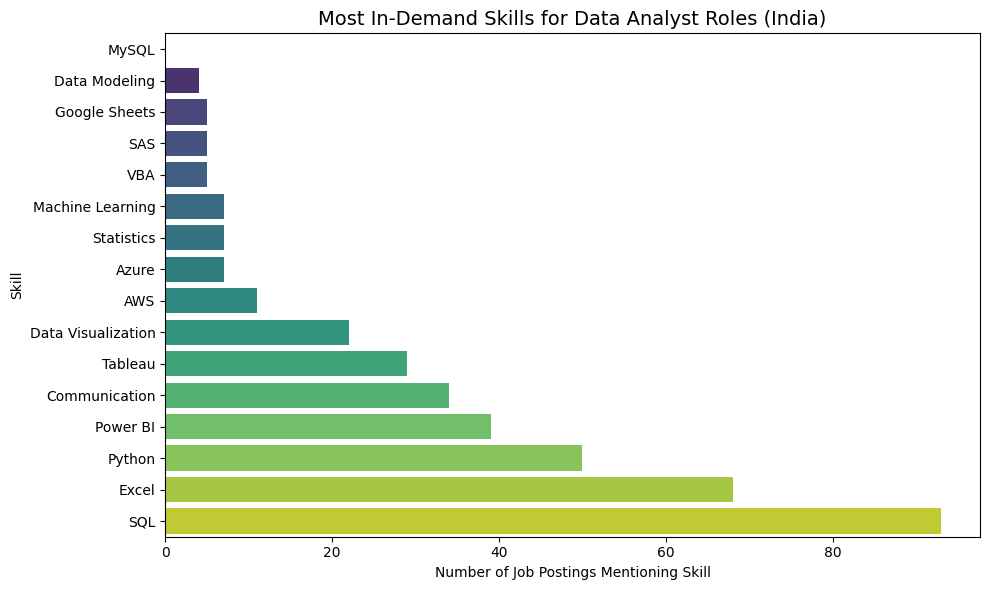

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
skill_counts_sorted = skill_counts.sort_values(ascending=True)
sns.barplot(x=skill_counts_sorted.values, y=skill_counts_sorted.index, hue=skill_counts_sorted.index, palette='viridis', legend=False)
plt.title('Most In-Demand Skills for Data Analyst Roles (India)', fontsize=14)
plt.xlabel('Number of Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

In [10]:
# Top cities with most job postings
top_locations = df['location'].value_counts().head(10)
print(top_locations)

location
India                   159
Bangalore, Karnataka    120
Hyderabad, Telangana     46
Mumbai, Maharashtra      33
Pune, Maharashtra        29
Chennai, Tamil Nadu      21
Gurgaon, Haryana         17
Noida, Ghaziabad         13
Ahmedabad, Gujarat        7
Delhi, India              7
Name: count, dtype: int64


In [11]:
# Top hiring companies
top_companies = df['company'].value_counts().head(10)
print(top_companies)

company
EXL                   18
Genpact               10
UnitedHealth Group    10
Guidehouse             9
Capco                  8
Wissen Technology      6
Barclays               6
Ecolab                 5
Qrata                  5
RELX INC               5
Name: count, dtype: int64


In [12]:
print("Jobs with specific city:", (df['location'] != 'India').sum())
print("Jobs with only 'India' (no city):", (df['location'] == 'India').sum())

Jobs with specific city: 341
Jobs with only 'India' (no city): 159


In [13]:
# Top 5 specific cities 
top_5_cities = df[df['location'] != 'India']['location'].value_counts().head(5).index.tolist()

# filter
city_df = df[df['location'].isin(top_5_cities)]

# Skills list
skills_list = ['Python', 'SQL', 'Excel', 'Google Sheets', 
               'Power BI', 'Tableau', 'Machine Learning', 
               'Statistics', 'AWS', 'Azure', 'SAS', 'VBA', 
               'Data Visualization', 'Data Modeling', 'Communication']

# city wise skill counts 
city_skill_matrix = city_df.groupby('location')[skills_list].sum()
print(city_skill_matrix)

                      Python  SQL  Excel  Google Sheets  Power BI  Tableau  \
location                                                                     
Bangalore, Karnataka      15   24     22              2        11        6   
Chennai, Tamil Nadu        1    4      1              0         3        2   
Hyderabad, Telangana       3   10      7              0         3        2   
Mumbai, Maharashtra        2    4      9              0         4        3   
Pune, Maharashtra          8   11      2              0         1        4   

                      Machine Learning  Statistics  AWS  Azure  SAS  VBA  \
location                                                                   
Bangalore, Karnataka                 3           2    1      2    1    0   
Chennai, Tamil Nadu                  1           0    0      1    0    0   
Hyderabad, Telangana                 0           0    1      0    0    0   
Mumbai, Maharashtra                  1           0    1      0    1    1 

In [14]:
print("Duplicate rows:", df.duplicated(subset=['id']).sum())
df = df.drop_duplicates(subset=['id'])
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (500, 28)


In [15]:
print(df.isnull().sum())

id                       0
title                    0
company                 11
location                 0
category                 0
contract_type          458
contract_time          178
created                  0
salary_min             399
salary_max             399
salary_is_predicted      0
description              0
redirect_url             0
Python                   0
SQL                      0
Excel                    0
Google Sheets            0
Power BI                 0
Tableau                  0
Machine Learning         0
Statistics               0
AWS                      0
Azure                    0
SAS                      0
VBA                      0
Data Visualization       0
Data Modeling            0
Communication            0
dtype: int64


In [16]:
df['company'] = df['company'].fillna('Not Specified')

df['contract_type'] = df['contract_type'].fillna('Not Specified')
df['contract_time'] = df['contract_time'].fillna('Not Specified')

df['created'] = pd.to_datetime(df['created'])
df['posted_date'] = df['created'].dt.date

df['location'] = df['location'].replace('India', 'Not Specified')

df['description'] = df['description'].str.strip()

print(df.isnull().sum())
print()
print("Unique companies:", df['company'].nunique())

id                       0
title                    0
company                  0
location                 0
category                 0
contract_type            0
contract_time            0
created                  0
salary_min             399
salary_max             399
salary_is_predicted      0
description              0
redirect_url             0
Python                   0
SQL                      0
Excel                    0
Google Sheets            0
Power BI                 0
Tableau                  0
Machine Learning         0
Statistics               0
AWS                      0
Azure                    0
SAS                      0
VBA                      0
Data Visualization       0
Data Modeling            0
Communication            0
posted_date              0
dtype: int64

Unique companies: 325


In [17]:
company_list = sorted(df['company'].unique())
print(company_list)

['3M', 'A.P. Moller - Maersk', 'ACE Money Transfer', 'ADP Private Limited', 'Accenture', 'Acura Solution', 'Advanced Energy', 'Albertsons Companies India', 'Align Technology', 'Aliqan Services', 'Amagi Media Labs', 'Amazon', 'Ameriprise', 'Amicus India', 'Amicus Therapeutics', 'Anaplan', 'Apex Group', 'Appitsimple infotek Pvt. Ltd.', 'Apraava Renewable Energy', 'Aptita', 'Arcadis', 'Arcana Analytics', 'Arise Global Services', 'Armstrong Fluid Technology', 'Arrow', 'Arrow Electronics', 'Aspyra Hr Services', 'Asterion', 'Avery Dennison', 'Awign', 'Ayoconnect Technology', 'Azent Overseas', 'Azira', 'BSR & Co', 'Bajaj Finance', 'Barclays', 'Beauto Systems Private Limited', 'Beworld web services', 'BitClass', 'Booking Holdings', 'CGI', 'CIEL HR Services', 'CONTUS TECH', 'CSB Bank', 'Cadila Zydus healthcare pvt ltd', 'Calderys Group', 'Campus Management', 'Capco', 'Capgemini', 'Caratlane', 'Carbynetech', 'Careernet', 'Cars24', 'Cars24 Services Private Limited', 'Cisco', 'Citigroup', 'Clariva

In [18]:
company_fixes = {
    'Criteo Technology': 'Criteo',
    'Danaher Corporation': 'Danaher',
    'Genpact India': 'Genpact',
    'Guidehouse India Pvt Ltd': 'Guidehouse',
    'Colan Infotech Private Limited': 'Colan Infotech',
    'Technogen India PvtLtd': 'Technogen',
    'TJX India': 'TJX',
    'WPP Production': 'WPP',
    'WPP Production Chennai': 'WPP',
    'RELX INC': 'RELX',
    'A.P. Moller - Maersk': 'Maersk',
    'intouchcx': 'InTouch CX',
    'Cars24 Services Private Limited': 'Cars24'
}

df['company'] = df['company'].replace(company_fixes)

df = df[df['company'] != 'Test']

print("Unique companies after cleaning:", df['company'].nunique())
print("Shape:", df.shape)

Unique companies after cleaning: 311
Shape: (499, 29)


In [19]:
print(df['contract_type'].value_counts())
print()
print(df['contract_time'].value_counts())

contract_type
Not Specified    457
contract          22
permanent         20
Name: count, dtype: int64

contract_time
full_time        316
Not Specified    177
part_time          6
Name: count, dtype: int64


In [20]:
print(df['category'].value_counts())

category
IT Jobs                             438
Accounting & Finance Jobs            20
PR, Advertising & Marketing Jobs      7
Scientific & QA Jobs                  5
Energy, Oil & Gas Jobs                5
HR & Recruitment Jobs                 4
Engineering Jobs                      4
Admin Jobs                            3
Creative & Design Jobs                3
Healthcare & Nursing Jobs             2
Trade & Construction Jobs             2
Consultancy Jobs                      2
Legal Jobs                            2
Manufacturing Jobs                    1
Sales Jobs                            1
Name: count, dtype: int64


In [21]:
print(df['posted_date'].value_counts().sort_index())

posted_date
2019-05-17     1
2019-06-05     4
2019-06-20     2
2019-11-27     1
2020-01-25     1
              ..
2026-07-29    11
2026-07-30    16
2026-07-31    26
2026-08-01    15
2026-08-02     2
Name: count, Length: 200, dtype: int64


In [22]:
salary_df = df[df['salary_min'].notna()]
print("Jobs with salary:", len(salary_df))
print(salary_df[['salary_min', 'salary_max']].describe())

Jobs with salary: 101
         salary_min    salary_max
count  1.010000e+02  1.010000e+02
mean   5.563564e+05  1.199614e+06
std    5.368128e+05  7.567067e+05
min    0.000000e+00  2.500000e+04
25%    1.000000e+05  7.000000e+05
50%    5.000000e+05  1.000000e+06
75%    8.000000e+05  1.500000e+06
max    2.500000e+06  4.000000e+06


In [23]:
print(df['title'].value_counts().head(15))

title
Data Analyst                 193
Senior Data Analyst           49
Sr. Data Analyst              10
Data Analyst 5B                9
Business Data Analyst          8
Lead Data Analyst              7
Data Analyst I                 5
Data Analyst 2                 4
Advanced Data Analyst          4
Data analyst                   4
Sr Data Analyst                4
Senior Data Analyst II         4
Reference Data Analyst         3
Site Data Analyst              3
Supply Chain Data Analyst      3
Name: count, dtype: int64


In [24]:
from datetime import datetime, timedelta

cutoff_date = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=180)
print("Jobs before cutoff (old):", (df['created'] < cutoff_date).sum())
df = df[df['created'] >= cutoff_date]
print("Shape after filtering old jobs:", df.shape)

Jobs before cutoff (old): 139
Shape after filtering old jobs: (360, 29)


In [25]:
def get_seniority(title):
    title_lower = str(title).lower()
    if 'senior' in title_lower or 'sr.' in title_lower or 'sr ' in title_lower or 'lead' in title_lower:
        return 'Senior'
    elif 'junior' in title_lower or 'jr.' in title_lower or 'jr ' in title_lower or 'intern' in title_lower:
        return 'Junior'
    else:
        return 'Mid/Not Specified'

df['seniority_level'] = df['title'].apply(get_seniority)
print(df['seniority_level'].value_counts())

seniority_level
Mid/Not Specified    262
Senior                90
Junior                 8
Name: count, dtype: int64


In [26]:
salary_seniority = df[df['salary_min'].notna()].groupby('seniority_level')[['salary_min', 'salary_max']].mean()
print(salary_seniority)

                      salary_min    salary_max
seniority_level                               
Mid/Not Specified  594285.714286  9.321429e+05
Senior             450000.000000  2.350000e+06


In [27]:
# Skill Combinations
df['skills_count'] = df[skills_list].sum(axis=1)
print(df['skills_count'].value_counts().sort_index())

python_sql = ((df['Python']) & (df['SQL'])).sum()
python_only = ((df['Python']) & (~df['SQL'])).sum()
sql_only = ((~df['Python']) & (df['SQL'])).sum()
print(f"Python+SQL together: {python_sql}")
print(f"Python only: {python_only}")
print(f"SQL only: {sql_only}")

skills_count
0    239
1     59
2     32
3     14
4      6
5      4
6      2
7      1
8      3
Name: count, dtype: int64
Python+SQL together: 23
Python only: 5
SQL only: 38


In [28]:
print(df[df['salary_min'].notna()]['seniority_level'].value_counts())

seniority_level
Mid/Not Specified    7
Senior               2
Name: count, dtype: int64


In [29]:
def get_work_mode(desc):
    desc_lower = str(desc).lower()
    if 'remote' in desc_lower or 'work from home' in desc_lower:
        return 'Remote'
    elif 'hybrid' in desc_lower:
        return 'Hybrid'
    else:
        return 'Onsite/Not Specified'

df['work_mode'] = df['description'].apply(get_work_mode)
print(df['work_mode'].value_counts())

work_mode
Onsite/Not Specified    340
Remote                   15
Hybrid                    5
Name: count, dtype: int64


In [30]:
from itertools import combinations

pair_counts = {}
for skill1, skill2 in combinations(skills_list, 2):
    count = ((df[skill1]) & (df[skill2])).sum()
    if count > 0:
        pair_counts[f"{skill1} + {skill2}"] = count

pair_series = pd.Series(pair_counts).sort_values(ascending=False)
print(pair_series.head(10))

Python + SQL           23
SQL + Power BI         22
SQL + Tableau          17
Power BI + Tableau     15
Excel + Power BI       14
SQL + Excel            13
Excel + Tableau        11
Python + Power BI      10
SQL + Communication    10
Python + Tableau        9
dtype: int64


In [31]:
salary_df = df[df['salary_min'].notna()].copy()

skill_salary = {}
for skill in skills_list:
    with_skill = salary_df[salary_df[skill] == True]['salary_max'].mean()
    without_skill = salary_df[salary_df[skill] == False]['salary_max'].mean()
    count_with = salary_df[skill].sum()
    if count_with >= 5:  # sirf jahan kam se kam 5 jobs hon, reliability ke liye
        skill_salary[skill] = {'avg_salary_with_skill': with_skill, 'jobs_count': count_with}

skill_salary_df = pd.DataFrame(skill_salary).T.sort_values('avg_salary_with_skill', ascending=False)
print(skill_salary_df)

     avg_salary_with_skill  jobs_count
SQL           1.504167e+06         6.0


In [32]:
df['posted_week'] = pd.to_datetime(df['posted_date']).dt.to_period('W').astype(str)
weekly_trend = df.groupby('posted_week').size()
print(weekly_trend)

posted_week
2026-02-16/2026-02-22     4
2026-02-23/2026-03-01     2
2026-03-02/2026-03-08     3
2026-03-09/2026-03-15     1
2026-03-23/2026-03-29     4
2026-03-30/2026-04-05     3
2026-04-06/2026-04-12     3
2026-04-13/2026-04-19     3
2026-04-20/2026-04-26     6
2026-04-27/2026-05-03     2
2026-05-04/2026-05-10     5
2026-05-11/2026-05-17    16
2026-05-18/2026-05-24     7
2026-05-25/2026-05-31     4
2026-06-01/2026-06-07    10
2026-06-08/2026-06-14    29
2026-06-15/2026-06-21     8
2026-06-22/2026-06-28    12
2026-06-29/2026-07-05    33
2026-07-06/2026-07-12    37
2026-07-13/2026-07-19    34
2026-07-20/2026-07-26    46
2026-07-27/2026-08-02    88
dtype: int64


In [33]:
salary_df = df[df['salary_min'].notna()].copy()

def skill_bucket(count):
    if count == 0:
        return '0 skills'
    elif count == 1:
        return '1 skill'
    elif count == 2:
        return '2 skills'
    else:
        return '3+ skills'

salary_df['skill_bucket'] = salary_df['skills_count'].apply(skill_bucket)
bucket_salary = salary_df.groupby('skill_bucket').agg(
    avg_salary=('salary_max', 'mean'),
    job_count=('salary_max', 'count')
).sort_values('avg_salary')

print(bucket_salary)

                avg_salary  job_count
skill_bucket                         
0 skills      7.333333e+05          3
1 skill       1.200000e+06          1
2 skills      1.200000e+06          2
3+ skills     1.808333e+06          3


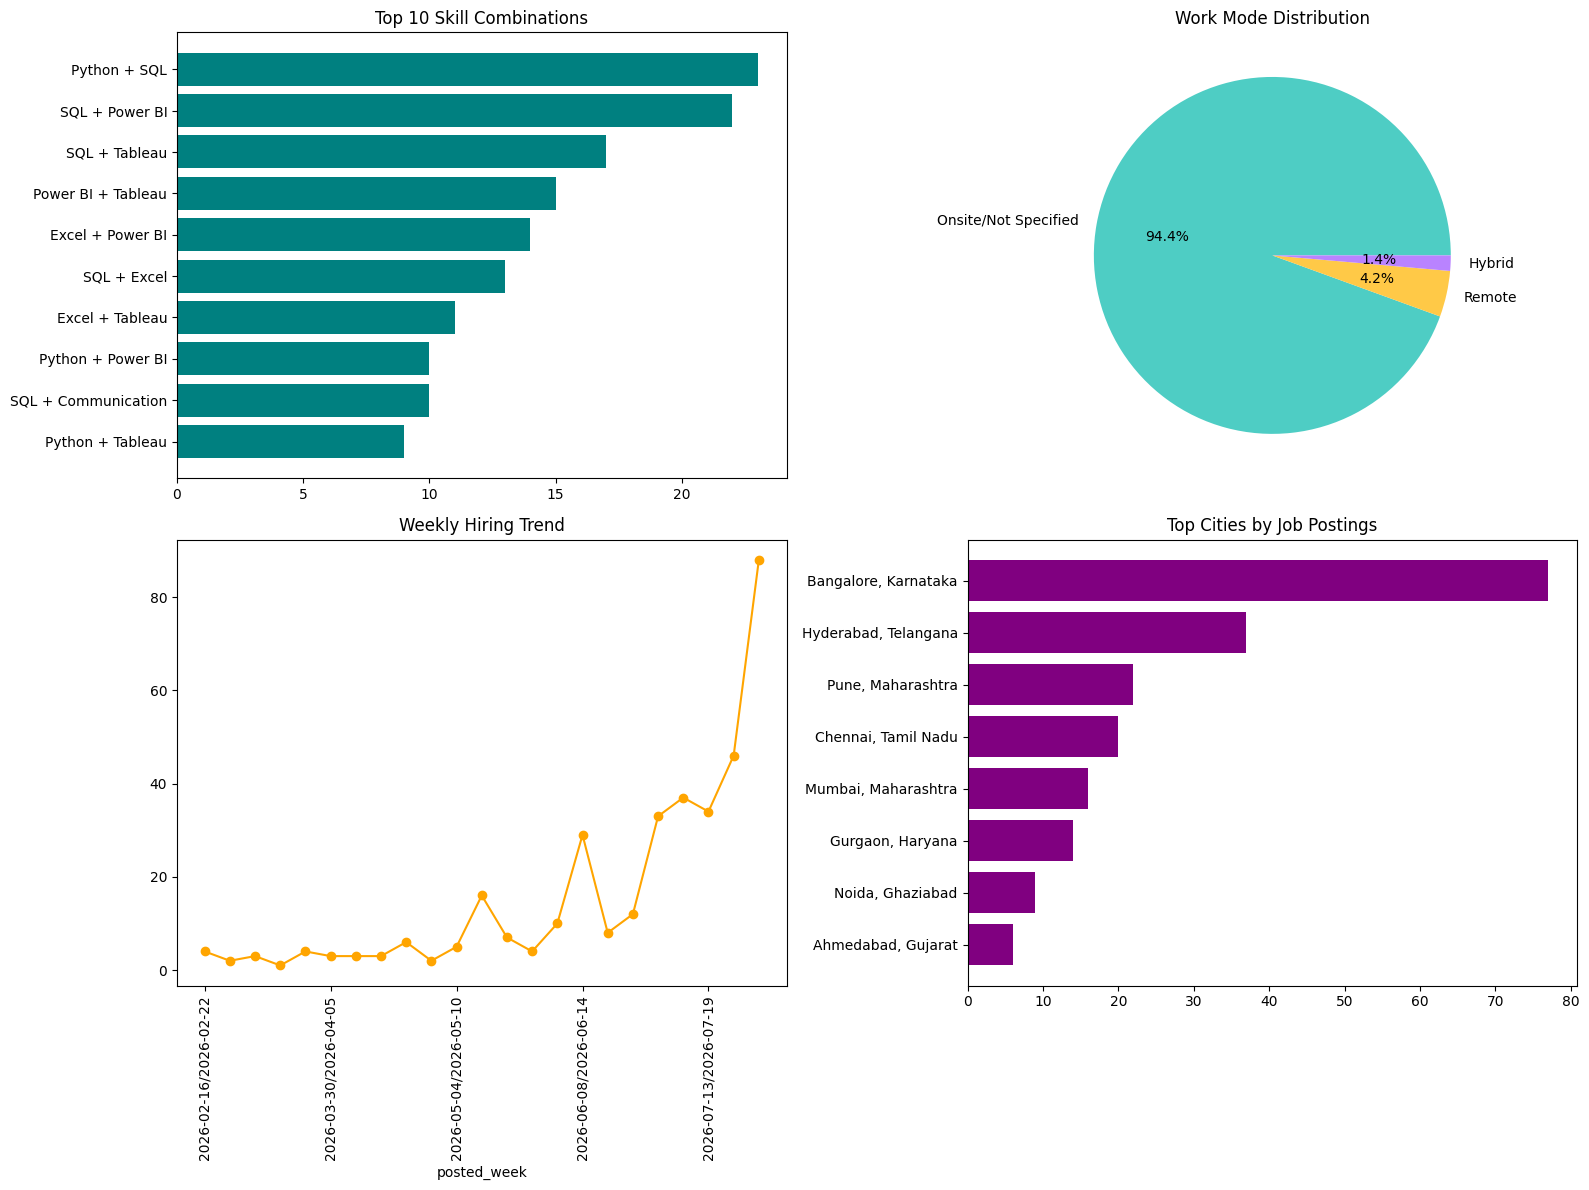

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top Skill Combinations
top_pairs = pair_series.head(10)
axes[0,0].barh(top_pairs.index[::-1], top_pairs.values[::-1], color='teal')
axes[0,0].set_title('Top 10 Skill Combinations')

# 2. Work Mode
work_mode_counts = df['work_mode'].value_counts()
axes[0,1].pie(work_mode_counts.values, labels=work_mode_counts.index, autopct='%1.1f%%', colors=['#4ECDC4','#FFC947','#B983FF'])
axes[0,1].set_title('Work Mode Distribution')

# 3. Weekly Hiring Trend
weekly_trend.plot(ax=axes[1,0], color='orange', marker='o')
axes[1,0].set_title('Weekly Hiring Trend')
axes[1,0].tick_params(axis='x', rotation=90)

# 4. Top Cities
top_locations_clean = df[df['location']!='Not Specified']['location'].value_counts().head(8)
axes[1,1].barh(top_locations_clean.index[::-1], top_locations_clean.values[::-1], color='purple')
axes[1,1].set_title('Top Cities by Job Postings')

plt.tight_layout()
plt.show()

In [38]:
df.to_csv('data_analyst_jobs_final.csv', index=False)
print("Final shape:", df.shape)

Final shape: (360, 33)
